In [1]:
import os
import sys
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy.io as sio
import scanpy.external as sce
import matplotlib.pyplot as plt
import re
import anndata as ad
import statistics
import torch
import scvi
import tempfile
import sklearn
import mudata as md
import muon as mu
import cosg
from scib_metrics.benchmark import Benchmarker
from scvi.model.utils import mde
from sklearn_ann.kneighbors.annoy import AnnoyTransformer
print("Last run with scvi-tools version:", scvi.__version__)
scvi.settings.num_threads = 4
scvi.settings.seed = 0
sc._settings.ScanpyConfig.n_jobs=24
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(8,8), format='png')
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 100)


import warnings
warnings.filterwarnings('ignore')

/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Impo

Last run with scvi-tools version: 1.2.0


In [2]:
sc.logging.print_header()

Package,Version
scipy,1.15.2
numpy,1.26.4
pandas,2.2.3
scanpy,1.11.0
seaborn,0.13.2
matplotlib,3.9.2
anndata,0.11.3
torch,2.4.1 (2.4.1+cu121)
scvi-tools,1.2.0
scikit-learn,1.5.2


In [3]:
def check_dict_duplicates(dict):
    seen = set()
    dup = any(item in seen or seen.add(item) for lst in dict.values() for item in lst)
    if dup==False:
        return '无重复'
    else:
        return '有重复'

In [4]:
obj_path = '/home/liyanguo/MyImmuCell/04_Ref_Atlas_scVI/'
sc.settings.figdir = obj_path

In [5]:
dataset = "Ref_Atlas"

# 1. Load data after cluster (raw count)

In [6]:
adata = sc.read_h5ad(f'{obj_path}{dataset}_umap_leiden_scVI.h5ad')

# 2. Set leiden group and identify cell identity

In [7]:
groupby = "L1_leiden_scVI_3"

In [8]:
adata.obs[groupby].value_counts()

L1_leiden_scVI_3
34    47947
21    43746
28    41913
11    41567
10    36216
24    35605
0     34855
25    33155
2     32756
19    32607
16    30080
8     29276
13    28878
7     26843
22    25764
12    24969
14    23904
17    23143
35    22508
31    22401
26    21761
6     21341
23    21033
38    20955
30    16163
39    15278
40    14642
33    14308
32    12411
41    11685
18    10924
9     10825
1      9113
29     8278
20     7874
15     7313
27     4734
36     4431
4      3406
5      3097
46     3018
43     2549
42     2504
37      940
45      626
3       489
44      389
47       28
48       12
Name: count, dtype: int64

In [9]:
adata

AnnData object with n_obs × n_vars = 888260 × 38606
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l1', 'predicted.celltype.l2', 'predicted.celltype.l3', 'scDblFinder.class', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'High_quality', 'Batch', 'L1_leiden_scVI_3', 'L1_leiden_scVI_4', 'L1_leiden_scVI_5'
    uns: 'L1_leiden_scVI_3', 'L1_leiden_scVI_3_colors', 'L1_leiden_scVI_4', 'L1_leiden_scVI_4_colors', 'L1_leiden_scVI_5', 'L1_leiden_scVI_5_colors', 'hvg', 'log1p', 'neighbors', 'umap'
 

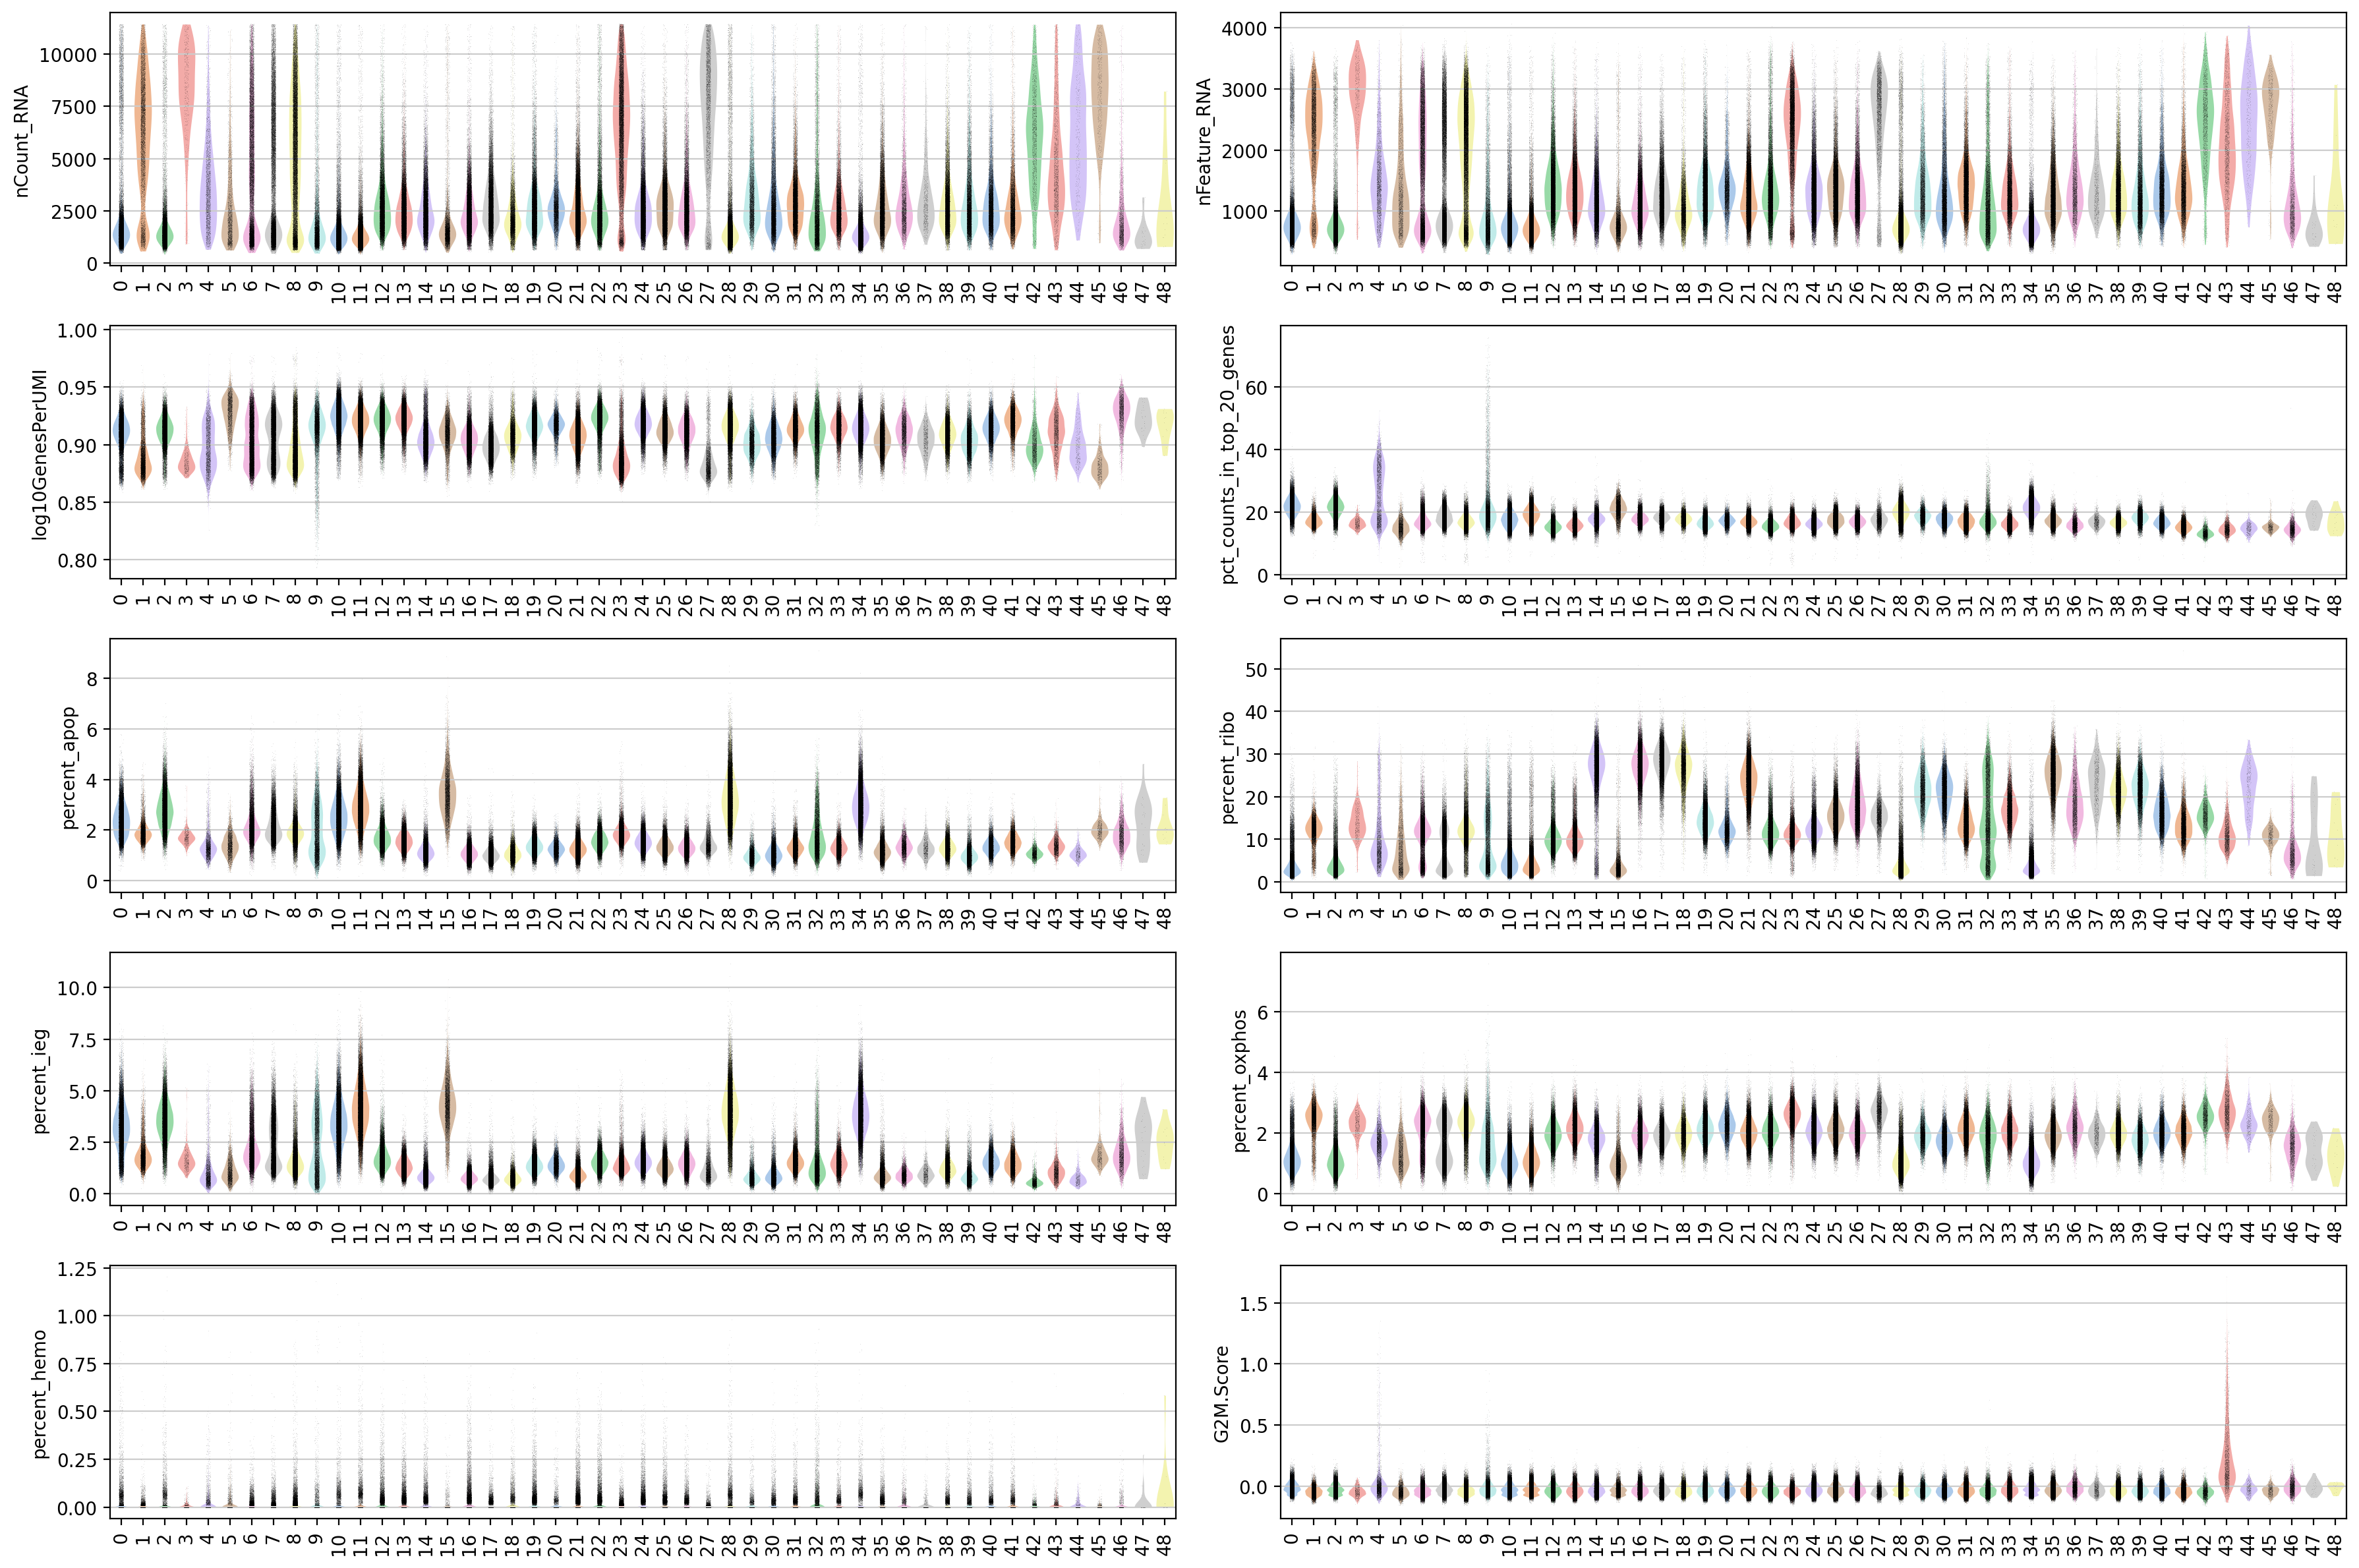

In [10]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='pct_counts_in_top_20_genes', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{dataset}_{groupby}_scVI_L1_metadata')

## 2.1 Clinical and Celltypist and Azimuth

In [11]:
xlsx = pd.ExcelWriter(f"{obj_path}{dataset}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class','Phase',
              'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l1', 'predicted.celltype.l2',
              'predicted.celltype.l3']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

## 2.2 COSG

In [12]:
cosg.cosg(adata, groupby=groupby,
          mu=1,n_genes_user=100,remove_lowly_expressed=True
         )

**finished identifying marker genes by COSG**


In [13]:
xlsx = pd.ExcelWriter(f"{obj_path}{dataset}_cosg_{groupby}.xlsx")
pd.DataFrame(adata.uns['rank_genes_groups']['names']).to_excel(xlsx,sheet_name='names')
pd.DataFrame(adata.uns['rank_genes_groups']['scores']).to_excel(xlsx,sheet_name='scores')
xlsx.close()

## 2.3 TCR BCR based annotation

In [14]:
#根据TCR识别部分细胞；TCR作为充分非必要条件
data_tcr = pd.read_csv("/home/liyanguo/MyImmuCell/02_Read_QC/scTCR_ref.csv",index_col=0)
data_bcr = pd.read_csv("/home/liyanguo/MyImmuCell/02_Read_QC/scBCR_ref.csv",index_col=0)

In [15]:
adata.obs = adata.obs.join(data_tcr, how='left')#TCR

In [16]:
adata.obs = adata.obs.join(data_bcr, how='left',rsuffix='_BCR')#BCR

In [17]:
adata.obs.receptor_type.value_counts()

receptor_type
TCR    329882
Name: count, dtype: int64

In [18]:
adata.obs.receptor_type_BCR.value_counts()

receptor_type_BCR
BCR    50773
Name: count, dtype: int64

In [19]:
xlsx = pd.ExcelWriter(f"{obj_path}{dataset}_freq_table_tcrbcr.xlsx")
for group in ['receptor_subtype', 
              'VJ_1_v_call', 'VJ_1_j_call', 
              'VDJ_1_v_call', 'VDJ_1_j_call',
              
              'receptor_type_BCR', 
              'VJ_1_v_call_BCR','VJ_1_j_call_BCR', 
              'VDJ_1_v_call_BCR', 'VDJ_1_j_call_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    freq_table_multi.to_excel(xlsx,sheet_name=group)
xlsx.close()

# 3. Cell_dict: fill in the clusters that belong to each cell type

In [20]:
cell_dict = {'Low quality':['5',#T淋巴都是有CD7的。但这类缺乏CD7 CD3D CD4基因表达，表达CD247、ETV6、ANK3、BACH2等基因,nCounts低
                   ],
             
             'Doublet':['3',#Monocyte和T混合，scDblFinder提示%87双细胞
                        '48',#T和Neu混合
                       ],

             'B|Plasma':['9',#B和Neu混合
                         '29',
                         '30',
                         '39',
                 ],
             
             'pDC':['42'],#

             'Classical monocyte':['1',#有污染，nCount略有异常
                                   '6',#Neu和Myeloid混合
                                   '7',#Neu和Myeloid混合
                                   '8',
                                  ],
             
             'Non-classical monocyte':['23',
                                       '45',#Neu和Monocyte混合，scDblFinder提示71%双细胞,
                                      ],
             
             'Dendritic':['27',],
             
             'Basophil':['46'],#KIT-

             'HSPC':['44'],#
             
             'Platelet':['32'],#

             'CEACAM8+ Neutrophil':['4'],
             
             'NK':['12',
                   '13',
                   '22',
                   '24',
                   '41'
                  ],

             'Proliferative T/NK':['43',],#MKI67, CD3+ SPON2+

             'γδ T':['40'],#scDblFinder提示20%双细胞
             'MAIT':['38'],#有CD4混合
             
             'CD4+ T': ['14',
                        '16',
                        '18',#
                        '21',
                        '25',
                        '35',
                        '36',
                        '37'
                       ],
             
             'CD8+ T':['17',
                       '19',
                       '20',
                       '26',
                       '31',
                       '33',
                       ],
             
             'CEACAM8- Neutrophil':['0',
                                    '2',
                                    '10',
                                    '11',
                                    '15',
                                    '28',
                                    '34',
                                    '47'
                                   ]
            }

In [21]:
cell_dict.values()

dict_values([['5'], ['3', '48'], ['9', '29', '30', '39'], ['42'], ['1', '6', '7', '8'], ['23', '45'], ['27'], ['46'], ['44'], ['32'], ['4'], ['12', '13', '22', '24', '41'], ['43'], ['40'], ['38'], ['14', '16', '18', '21', '25', '35', '36', '37'], ['17', '19', '20', '26', '31', '33'], ['0', '2', '10', '11', '15', '28', '34', '47']])

In [22]:
check_dict_duplicates(cell_dict)

'无重复'

In [23]:
adata

AnnData object with n_obs × n_vars = 888260 × 38606
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l1', 'predicted.celltype.l2', 'predicted.celltype.l3', 'scDblFinder.class', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'High_quality', 'Batch', 'L1_leiden_scVI_3', 'L1_leiden_scVI_4', 'L1_leiden_scVI_5', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'VJ_1_locus', 'VJ_1_v_call', 'VJ_1_j_call', 'VJ_1_junction_aa', 'VJ_1_junction', 'VJ_1_umi_count', 'VDJ_1_locus', 'VDJ_1_v_call', 'V

del adata.obs['Celltype_L1_L2']

In [25]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2'] = i

In [26]:
#MAIT; TRAV1-2; The MAIT cell is dominated by cells that express a semi-invariant αβ TCR: Vα7.2–Jα33 in humans that is paired with a Vβ2 or Vβ13 chain
adata.obs.loc[(adata.obs['VJ_1_v_call']=='TRAV1-2') & ((adata.obs['VJ_1_j_call']=='TRAJ33') | (adata.obs['VJ_1_j_call']=='TRAJ12') | (adata.obs['VJ_1_j_call']=='TRAJ20')),'Celltype_L1_L2']="MAIT"

In [27]:
#iNKT: Vα24-Jα18/Vβ11 chains in humans
adata.obs.loc[(adata.obs['VJ_1_v_call']=='TRAV24') & (adata.obs['VJ_1_j_call']=='TRAJ18'),'Celltype_L1_L2']="iNKT"

In [28]:
(adata.obs['Celltype_L1_L2'].isna()).value_counts()

Celltype_L1_L2
False    888260
Name: count, dtype: int64

In [29]:
adata.obs['Celltype_L1_L2_Refine']=adata.obs['Celltype_L1_L2']

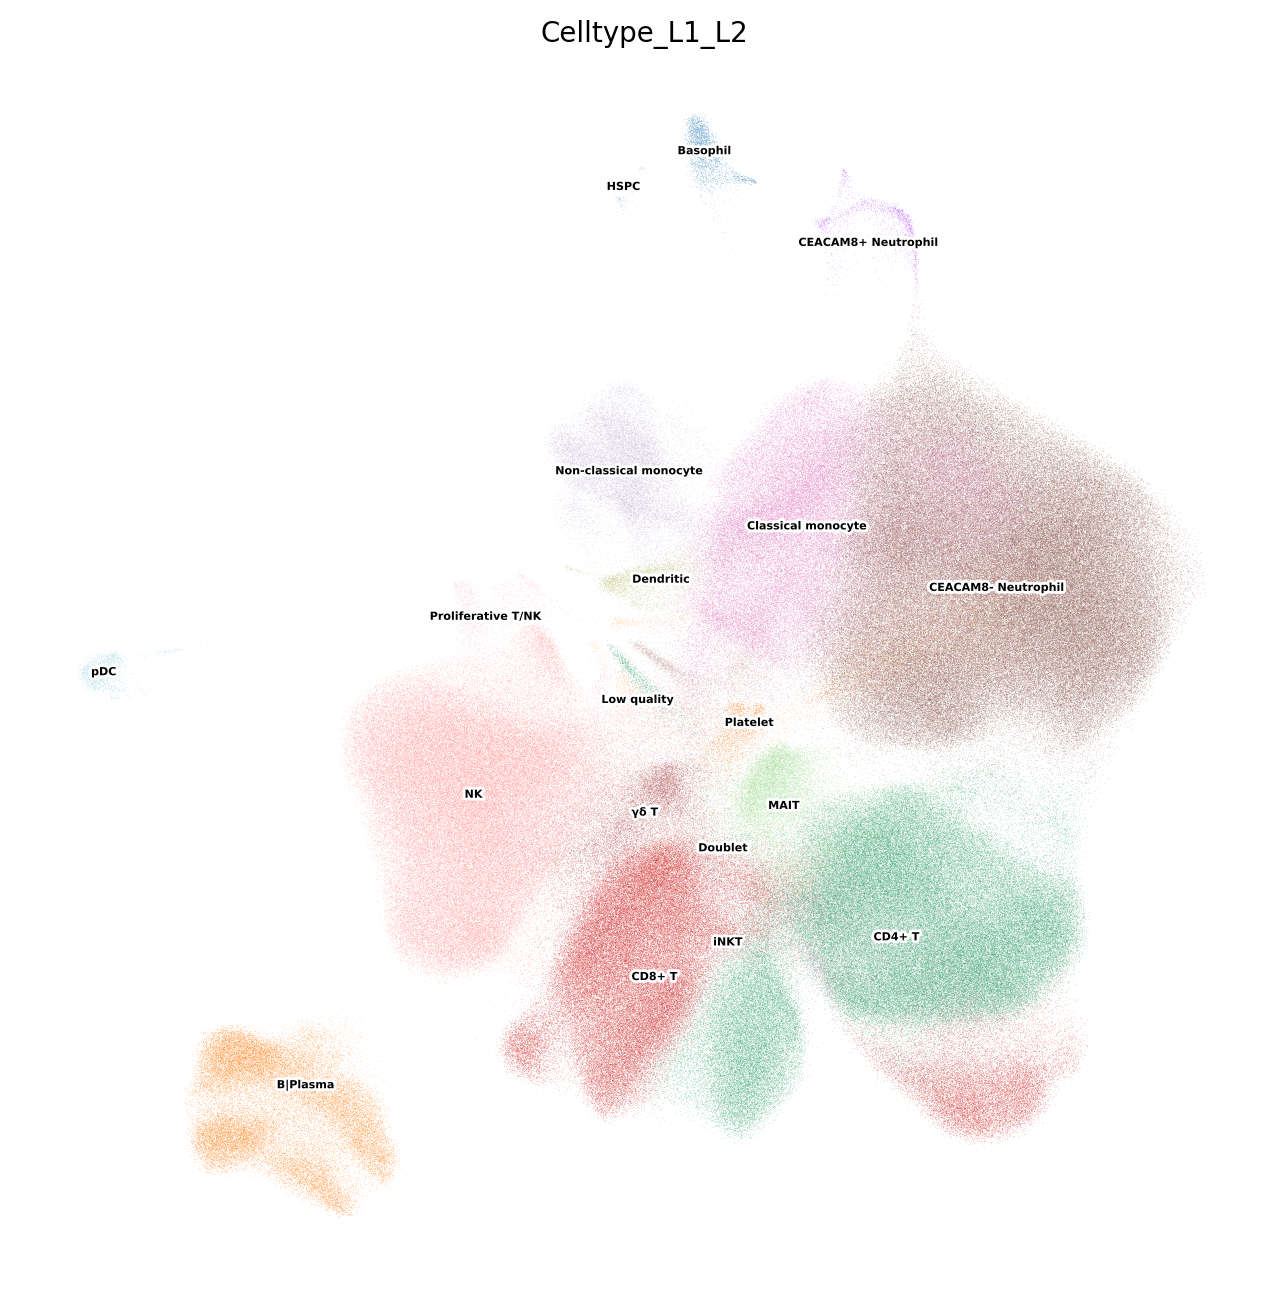

In [30]:
sc.pl.umap(adata, color=['Celltype_L1_L2'],
           save=f'{dataset}_Celltype_L1_L2',
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=0.1,
           legend_loc='on data')

In [31]:
xlsx = pd.ExcelWriter(f"{obj_path}{dataset}_Celltype_prop.xlsx")
pd.DataFrame(adata.obs.groupby(['SampleID','Celltype_L1_L2']).size()).to_excel(xlsx,sheet_name='SampleID_Celltype_L1_L2')
pd.DataFrame(adata.obs.groupby(['Celltype_L1_L2']).size()).to_excel(xlsx,sheet_name='Celltype_L1_L2')
xlsx.close()

# 4. Level1 and Level2 Refine, Round1.

In [32]:
adata.obs.Celltype_L1_L2.value_counts()

Celltype_L1_L2
CEACAM8- Neutrophil       242504
CD4+ T                    169312
NK                        126749
CD8+ T                    121700
Classical monocyte         86519
B|Plasma                   50422
MAIT                       22314
Non-classical monocyte     21635
γδ T                       14576
Platelet                   12348
Dendritic                   4730
CEACAM8+ Neutrophil         3398
Low quality                 3091
Basophil                    3010
Proliferative T/NK          2529
pDC                         2492
Doublet                      498
HSPC                         389
iNKT                          44
Name: count, dtype: int64

In [33]:
CEACAM8_Neg_Neutrophil=adata[adata.obs['Celltype_L1_L2'].isin(['CEACAM8- Neutrophil']), :]
CEACAM8_Neg_Neutrophil.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
CEACAM8- Neutrophil    242504
Name: count, dtype: int64

In [34]:
CEACAM8_Pos_Neutrophil=adata[adata.obs['Celltype_L1_L2'].isin(['CEACAM8+ Neutrophil']), :]
CEACAM8_Pos_Neutrophil.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
CEACAM8+ Neutrophil    3398
Name: count, dtype: int64

In [35]:
Monocyte=adata[adata.obs['Celltype_L1_L2'].isin(['Classical monocyte','Non-classical monocyte']), :]
Monocyte.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
Classical monocyte        86519
Non-classical monocyte    21635
Name: count, dtype: int64

In [36]:
NK=adata[adata.obs['Celltype_L1_L2'].isin(['NK']), :]
NK.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
NK    126749
Name: count, dtype: int64

In [37]:
CD4T=adata[adata.obs['Celltype_L1_L2'].isin(['CD4+ T']), :]
CD4T.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
CD4+ T    169312
Name: count, dtype: int64

In [38]:
CD8T=adata[adata.obs['Celltype_L1_L2'].isin(['CD8+ T']), :]
CD8T.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
CD8+ T    121700
Name: count, dtype: int64

In [39]:
MAIT=adata[adata.obs['Celltype_L1_L2'].isin(['MAIT']), :]
MAIT.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
MAIT    22314
Name: count, dtype: int64

In [40]:
gdT=adata[adata.obs['Celltype_L1_L2'].isin(['γδ T']), :]
gdT.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
γδ T    14576
Name: count, dtype: int64

In [41]:
Proliferative_TNK=adata[adata.obs['Celltype_L1_L2'].isin(['Proliferative T/NK']), :]
Proliferative_TNK.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
Proliferative T/NK    2529
Name: count, dtype: int64

In [42]:
iNKT=adata[adata.obs['Celltype_L1_L2'].isin(['iNKT']), :]
iNKT.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
iNKT    44
Name: count, dtype: int64

In [43]:
B=adata[adata.obs['Celltype_L1_L2'].isin(['B|Plasma']), :]
B.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
B|Plasma    50422
Name: count, dtype: int64

In [44]:
#Plasma=adata[adata.obs['Celltype_L1_L2'].isin(['Plasma']), :]
#Plasma.obs['Celltype_L1_L2'].value_counts()

In [45]:
Platelet=adata[adata.obs['Celltype_L1_L2'].isin(['Platelet']), :]
Platelet.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
Platelet    12348
Name: count, dtype: int64

In [46]:
Basophil=adata[adata.obs['Celltype_L1_L2'].isin(['Basophil']), :]
Basophil.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
Basophil    3010
Name: count, dtype: int64

In [47]:
pDC=adata[adata.obs['Celltype_L1_L2'].isin(['pDC']), :]
pDC.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
pDC    2492
Name: count, dtype: int64

In [54]:
Dendritic=adata[adata.obs['Celltype_L1_L2'].isin(['Dendritic']), :]
Dendritic.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
Dendritic    4730
Name: count, dtype: int64

In [49]:
HSPC=adata[adata.obs['Celltype_L1_L2'].isin(['HSPC']), :]
HSPC.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
HSPC    389
Name: count, dtype: int64

In [50]:
L2_refine_path='/home/liyanguo/MyImmuCell/05_Ref_Atlas_subpopulation/'

In [51]:
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/Monocyte', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/CEACAM8_Pos_Neutrophil', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/CEACAM8_Neg_Neutrophil', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/NK', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/CD8T', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/CD4T', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/MAIT', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/gdT', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/Proliferative_TNK', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/iNKT', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/B', exist_ok=True)
#os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/Plasma', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/Platelet', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/Basophil', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/Dendritic', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/pDC', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/HSPC', exist_ok=True)

In [52]:
adata.write_h5ad(f'{obj_path}{dataset}_Celltype_L1_L2_scVI.h5ad')

## save H5ad

In [53]:
CEACAM8_Pos_Neutrophil.write(f"{L2_refine_path}/Level2_Refine_R1/CEACAM8_Pos_Neutrophil/CEACAM8_Pos_Neutrophil.h5ad",compression="gzip")
CEACAM8_Neg_Neutrophil.write(f"{L2_refine_path}/Level2_Refine_R1/CEACAM8_Neg_Neutrophil/CEACAM8_Neg_Neutrophil.h5ad",compression="gzip")
Monocyte.write(f"{L2_refine_path}/Level2_Refine_R1/Monocyte/Monocyte.h5ad",compression="gzip")
NK.write(f"{L2_refine_path}/Level2_Refine_R1/NK/NK.h5ad",compression="gzip")
CD8T.write(f"{L2_refine_path}/Level2_Refine_R1/CD8T/CD8T.h5ad",compression="gzip")
CD4T.write(f"{L2_refine_path}/Level2_Refine_R1/CD4T/CD4T.h5ad",compression="gzip")
MAIT.write(f"{L2_refine_path}/Level2_Refine_R1/MAIT/MAIT.h5ad",compression="gzip")
gdT.write(f"{L2_refine_path}/Level2_Refine_R1/gdT/gdT.h5ad",compression="gzip")
Proliferative_TNK.write(f"{L2_refine_path}/Level2_Refine_R1/Proliferative_TNK/Proliferative_TNK.h5ad",compression="gzip")
iNKT.write(f"{L2_refine_path}/Level2_Refine_R1/iNKT/iNKT.h5ad",compression="gzip")
B.write(f"{L2_refine_path}/Level2_Refine_R1/B/B.h5ad",compression="gzip")
#Plasma.write(f"{L2_refine_path}/Level2_Refine_R1/Plasma/Plasma.h5ad",compression="gzip")
Platelet.write(f"{L2_refine_path}/Level2_Refine_R1/Platelet/Platelet.h5ad",compression="gzip")
Basophil.write(f"{L2_refine_path}/Level2_Refine_R1/Basophil/Basophil.h5ad",compression="gzip")
Dendritic.write(f"{L2_refine_path}/Level2_Refine_R1/Dendritic/Dendritic.h5ad",compression="gzip")
pDC.write(f"{L2_refine_path}/Level2_Refine_R1/pDC/pDC.h5ad",compression="gzip")
HSPC.write(f"{L2_refine_path}/Level2_Refine_R1/HSPC/HSPC.h5ad",compression="gzip")